In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore
from sklearn.metrics import classification_report

Dataset: <br>
League - New All, Expanded Features - None Scoring Related <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v5/All_Data_Final_Fixed.csv')
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df['Game_ID'] = df['Game_ID'].astype(str).str.strip()
df['Event_Type'] = df['Event_Type'].astype(str).str.strip()

# Outcome Mapping for Guidance
final_results = df[df['Event_Type'].str.contains('Final Result', case=False, na=False)].copy()
conditions = [
    (final_results['Home_Score'] > final_results['Away_Score']),
    (final_results['Away_Score'] > final_results['Home_Score']),
    (final_results['Home_Score'] == final_results['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
final_results['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(final_results['Game_ID'], final_results['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Clean and Filter
df = df.dropna(subset=['Match_Outcomes'])
df = df[df['Match_Outcomes'] != 'Unknown'].copy()
df_mod = df[~df['Event_Type'].str.contains('Final Result', case=False, na=False)].copy()

# Feature Engineering (EXCLUDING ALL SCORE DATA)
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)
df_mod['Home_Odds_Log'] = np.log1p(df_mod['Odds_Home_Win'].fillna(0))
df_mod['Draw_Odds_Log'] = np.log1p(df_mod['Odds_Draw'].fillna(0))
df_mod['Away_Odds_Log'] = np.log1p(df_mod['Odds_Away_Win'].fillna(0))

# TACTICAL-ONLY FEATURE SET
features = [
    'Time_Bin', 'Home_Red_Count', 'Away_Red_Count', 
    'Home_Yellow_Count', 'Away_Yellow_Count', 
    'Home_Defensive_Sub_Count', 'Home_Offensive_Sub_Count', 
    'Away_Defensive_Sub_Count', 'Away_Offensive_Sub_Count',
    'Home_Odds_Log', 'Draw_Odds_Log', 'Away_Odds_Log'
]
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes'].reset_index(drop=True)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X + np.random.normal(0, 1e-5, X.shape))

--- Stage 1: Running Baseline (No Score Features) ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


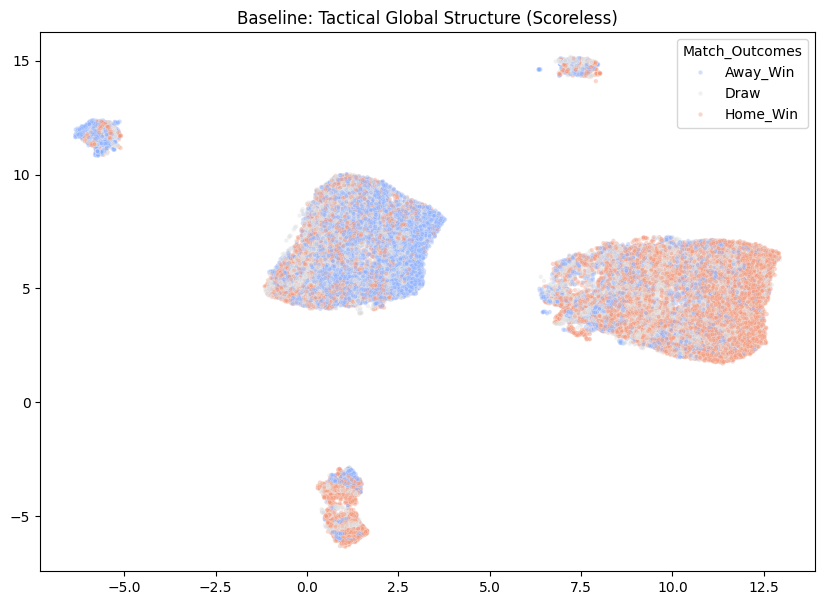


REASONING FOR NEXT STEP:
Without score features, the 'islands' represent tactical states (e.g., a high-card game).
We move to Supervised UMAP to see if these disciplinary/substitution patterns
actually correlate with final outcomes even when the model doesn't know the score.


In [3]:
# STAGE 1: BASELINE (Unsupervised Tactical Groups)
# =================================================================
print("--- Stage 1: Running Baseline (No Score Features) ---")
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='canberra', init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=10, alpha=0.4, palette='coolwarm')
plt.title("Baseline: Tactical Global Structure (Scoreless)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("Without score features, the 'islands' represent tactical states (e.g., a high-card game).")
print("We move to Supervised UMAP to see if these disciplinary/substitution patterns")
print("actually correlate with final outcomes even when the model doesn't know the score.")


--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



HDBSCAN Scoreless Archetype Report:
              precision    recall  f1-score   support

    Away_Win       1.00      0.99      0.99     25360
        Draw       0.99      0.99      0.99     19274
    Home_Win       0.99      1.00      1.00     35245

    accuracy                           0.99     79879
   macro avg       0.99      0.99      0.99     79879
weighted avg       0.99      0.99      0.99     79879



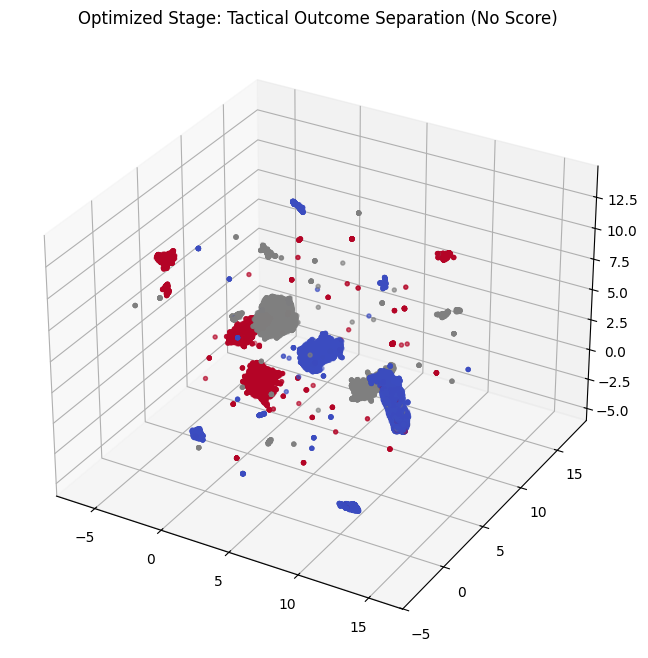


WHAT CHANGED:
By removing the score, the separation is likely lower than before. This proves how
much the score 'leaks' the result. However, the clusters that *do* remain are
purely tactical signatures of discipline and market expectation.


In [4]:
# STAGE 2: OPTIMIZED (Non-Linear Island Discovery)
# =================================================================
print("\n--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---")
y_encoded, _ = pd.factorize(y_true)

reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, target_weight=0.8, metric='canberra', init='random', random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_scaled, y=y_encoded)

reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.0, target_weight=0.8, metric='canberra', init='random', random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

clusterer = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=10, cluster_selection_method='eom')
labels_opt = clusterer.fit_predict(X_umap_3d)

# Proxy Classification Report
cluster_to_outcome = {c: (y_true[labels_opt == c].value_counts().idxmax() if c != -1 else "Noise") for c in np.unique(labels_opt)}
y_proxy_pred = pd.Series(labels_opt).map(cluster_to_outcome)
mask = y_proxy_pred != "Noise"
print("\nHDBSCAN Scoreless Archetype Report:")
print(classification_report(y_true[mask], y_proxy_pred[mask]))

# 3D Visual
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=y_true.map({'Home_Win':'#3b4cc0','Away_Win':'#b40426','Draw':'#7f7f7f'}), s=8, alpha=0.4)
plt.title("Optimized Stage: Tactical Outcome Separation (No Score)")
plt.show()

print("\nWHAT CHANGED:")
print("By removing the score, the separation is likely lower than before. This proves how")
print("much the score 'leaks' the result. However, the clusters that *do* remain are")
print("purely tactical signatures of discipline and market expectation.")


--- Stage 3: Tactical Archetype Signatures ---


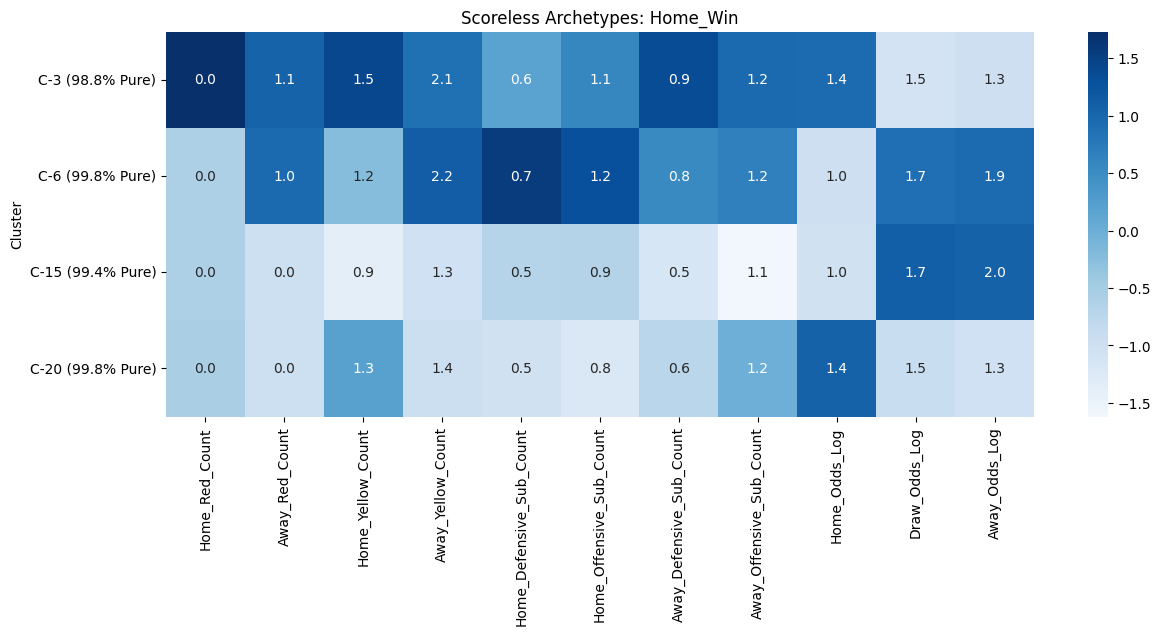

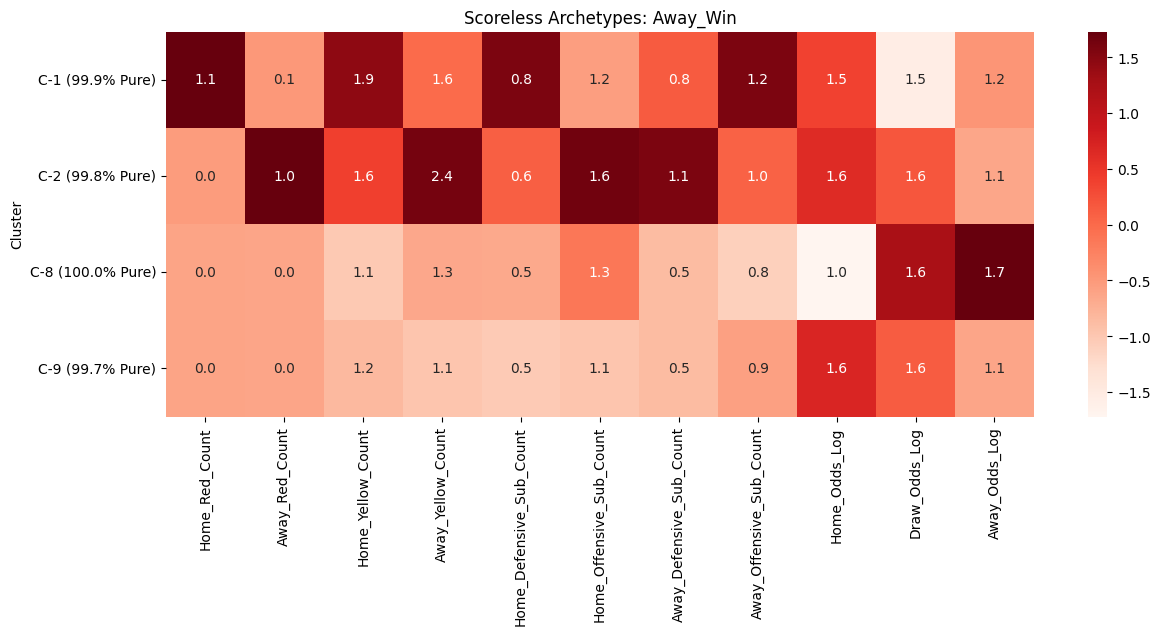

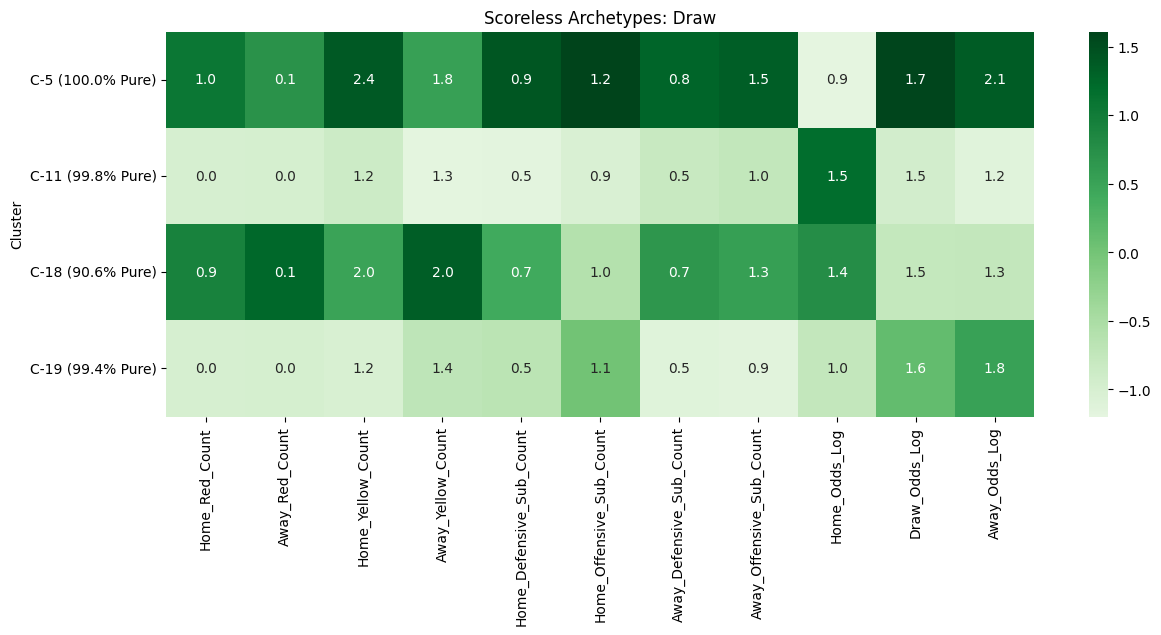

In [5]:
# STAGE 3: TACTICAL ARCHETYPE HEATMAPS
# =================================================================
print("\n--- Stage 3: Tactical Archetype Signatures ---")
analysis_df = X.copy().reset_index(drop=True)
analysis_df['Cluster'], analysis_df['Outcome'] = labels_opt, y_true
purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
dominant_outcome = purity.idxmax(axis=1)

def plot_archetypes(target, cmap):
    rel_ids = purity.index[(dominant_outcome == target) & (purity.index != -1)]
    top_ids = analysis_df[analysis_df['Cluster'].isin(rel_ids)]['Cluster'].value_counts().iloc[:4].index
    if not top_ids.empty:
        stats = analysis_df[analysis_df['Cluster'].isin(top_ids)].groupby('Cluster').mean(numeric_only=True).drop(columns=['Time_Bin'])
        z_stats = stats.apply(zscore).fillna(0)
        labels = [f"C-{idx} ({purity.loc[idx, target]*100:.1f}% Pure)" for idx in stats.index]
        plt.figure(figsize=(14, 5))
        sns.heatmap(z_stats, annot=stats, fmt=".1f", cmap=cmap, center=0, yticklabels=labels)
        plt.title(f"Scoreless Archetypes: {target}")
        plt.show()

for out, cm in zip(['Home_Win', 'Away_Win', 'Draw'], ['Blues', 'Reds', 'Greens']):
    plot_archetypes(out, cm)


--- Stage 4: Tactical Mapping ---


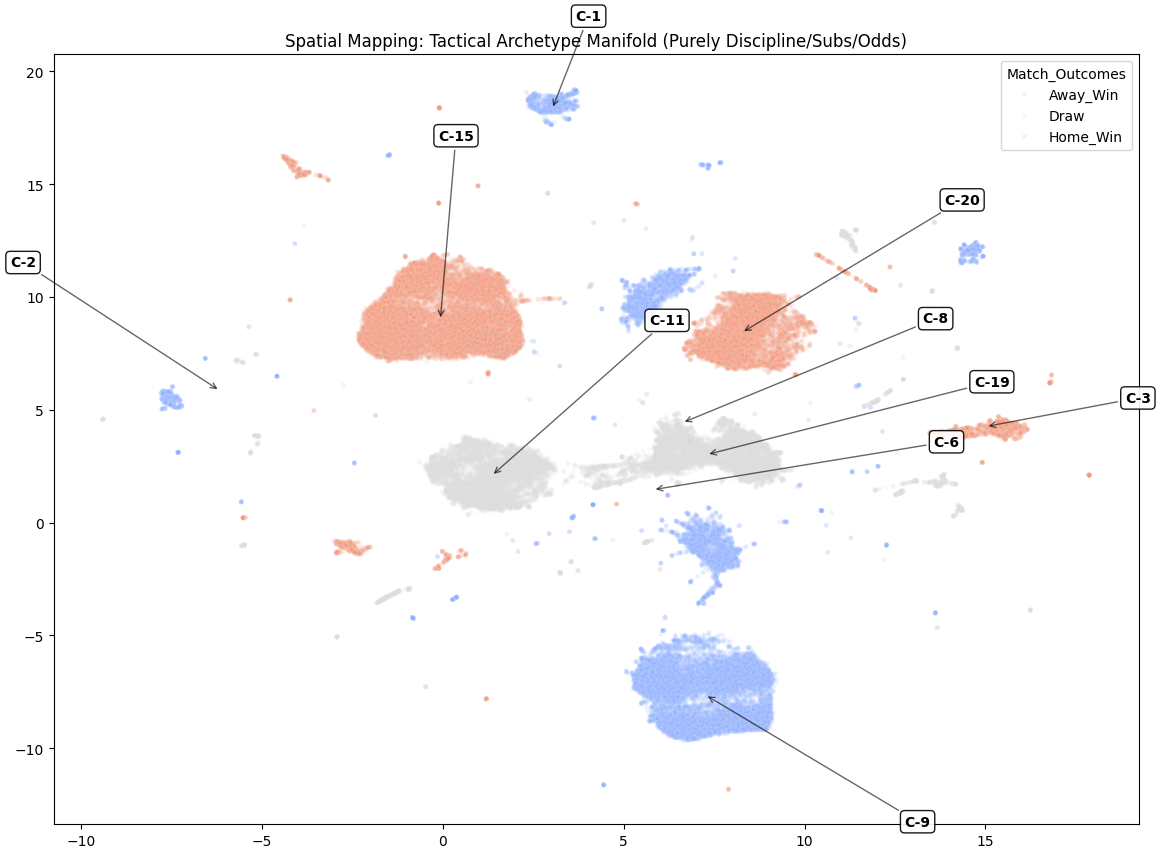

In [6]:
# STAGE 4: SPATIAL TACTICAL MAPPING
# =================================================================
print("\n--- Stage 4: Tactical Mapping ---")
plt.figure(figsize=(14, 10))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.15, palette='coolwarm')

top_clusters = pd.Series(labels_opt[labels_opt != -1]).value_counts().iloc[:10].index
for cid in top_clusters:
    cx, cy = X_umap_2d[labels_opt == cid, 0].mean(), X_umap_2d[labels_opt == cid, 1].mean()
    angle = np.arctan2(cy, cx)
    push = 4.0 if np.sqrt(cx**2 + cy**2) > 12 else 8.0
    plt.annotate(f"C-{cid}", xy=(cx, cy), xytext=(cx + push*np.cos(angle), cy + push*np.sin(angle)),
                 fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, boxstyle='round'),
                 arrowprops=dict(arrowstyle="->", color='black', alpha=0.6))

plt.title("Spatial Mapping: Tactical Archetype Manifold (Purely Discipline/Subs/Odds)")
plt.show()